# 7. Advanced simulation: Population fitting and subcatchment aggregation
The examples up to this point have focused on demonstrating the different features an object types within pySIMDEUM using a small collection of houses at most. However, in practice, pySIMDEUM is likely to be used to simulate large number of houses at once and built a representation of water usage, and/or discharge of wastewater into the sewer network.

We will cover two scenarios here:

1) A manual way, simulating multiple houses using demographic stats from your config files.
2) Simulate multiple houses using `build_multi_hh()` method in the api if the occupancy type of a household is already known.
3) A more advanced method in which we use census population counts and boundaries to fit occupancy type to specific house locations, and then simulate based on these occupancy types. A further step of using subcatchment boundaries to aggregate household wastewater profiles is also included.

## 1) Manual method: config file demographic stats

In other examples, you will notice that we have used the `built_house()` method to generate a house, we can use a similar structure of code to achieve this for multiple houses.


In [1]:
import pysimdeum
from pysimdeum.core.house import Property
from pysimdeum.core.statistics import Statistics

In [2]:
houses = []
number_of_houses = 3 

for _i in range(number_of_houses):
    stats = Statistics()
    prop = Property(statistics=stats)
    house = prop.built_house()
    house.populate_house()
    house.furnish_house()
    for user in house.users:
        user.compute_presence(statistics=stats)
    house.simulate()
    houses.append(house)

houses

[House:
 	id	=	6ee65c6d-2a15-443b-940d-fc4b737067f2
 	type	=	one_person
 	user	=	1
 	appliances	=	['WcNormalSave', 'BathroomTap', 'KitchenTap', 'OutsideTap', 'FancyShower', 'WashingMachine'],
 House:
 	id	=	6ee65c6d-2a15-443b-940d-fc4b737067f2
 	type	=	two_person
 	user	=	2
 	appliances	=	['WcNew', 'Bathtub', 'BathroomTap', 'Dishwasher', 'KitchenTap', 'OutsideTap', 'FancyShower', 'WashingMachine'],
 House:
 	id	=	6ee65c6d-2a15-443b-940d-fc4b737067f2
 	type	=	family
 	user	=	5
 	appliances	=	['WcNormal', 'Bathtub', 'BathroomTap', 'Dishwasher', 'KitchenTap', 'FancyShower', 'WashingMachine']]

You can access each `House` object from the `houses` list as normal and view plot or write files.

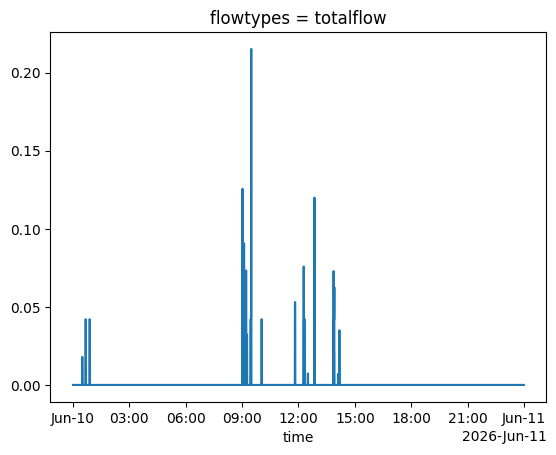

In [3]:
houses[0].consumption.sum(["user","enduse","patterns"]).sel(flowtypes="totalflow").plot()

## 2) `build_multi_hh()` method

This method assumes you have a list of houses with unique ids and occupancy type pre-assigned. In our case we will just generate a demo dictionary of what this input might look like so the expected input format is clear.


In [4]:
household_dict = {
    "hh_1": "one_person",
    "hh_2": "two_person",
    "hh_3": "family"
}

household_dict

{'hh_1': 'one_person', 'hh_2': 'two_person', 'hh_3': 'family'}

You can provide the regular inputs on simulation duration, inclusion of discharge and use of spillover feature. Notice the house ids and occupancy type being carried through the simulation into the `House` objects.

In [5]:
houses = pysimdeum.build_multi_hh(
    household_data=household_dict,
    duration='1 day',
    country='UK',
    simulate_discharge=False,
    spillover=False
    )

houses

Simulating households: 100%|██████████| 3/3 [00:00<00:00,  6.60hh/s]


{'hh_1': House:
 	id	=	6ee65c6d-2a15-443b-940d-fc4b737067f2
 	type	=	one_person
 	user	=	1
 	appliances	=	['WcNewSave', 'Bathtub', 'BathroomTap', 'KitchenTap', 'FancyShower', 'WashingMachine'],
 'hh_2': House:
 	id	=	6ee65c6d-2a15-443b-940d-fc4b737067f2
 	type	=	two_person
 	user	=	2
 	appliances	=	['WcNew', 'Bathtub', 'BathroomTap', 'Dishwasher', 'KitchenTap', 'OutsideTap', 'NormalShower', 'WashingMachine'],
 'hh_3': House:
 	id	=	6ee65c6d-2a15-443b-940d-fc4b737067f2
 	type	=	family
 	user	=	4
 	appliances	=	['WcNew', 'Bathtub', 'BathroomTap', 'Dishwasher', 'KitchenTap', 'OutsideTap', 'FancyShower', 'WashingMachine']}

## 3) `Population` method: population fitting and subcatchment aggregation

This final method provides a way of feeding in granular census population counts for boundaries within your study area. In the UK, this might look like providing output area boundaries and their population counts as well as house locations. An extra file representing subcatchments is included to help aggregate household wastewater profiles together.

This method is supported by the `DataPrep` class and `spatial_config.toml` which together help prepare the various input files needed for this method into a standardised format that works with the `Population` method.

Data files needed and their expected columns are:
* Census boundaries file (e.g. `.geojson`)
    * census boundary ids
    * geometry
* Census population count (with ids matching boundaries file)
    * census boundary ids
    * population count
* House location points (unique ids)
    * ids
    * building type (assuming file includes mix of resi and non-resi)
* Subcatchment boundaries (e.g. `.geojson`)
    * ids
    * geometry

The `DataPrep` class and `spatial_config.toml` essentially help map column ids from your raw dataset to the expected inputs for the `Population` method. We can read in the config file to just understand the different sections. The first section `dataset` is the file path to each of your respective files.

In [6]:
import os
import toml
from pysimdeum.data import DATA_DIR
from pysimdeum.core.population import DataPrep, Population
import folium

spatial_config = toml.load(os.path.join(DATA_DIR, "UK", 'spatial_config.toml'))

In [7]:
spatial_config['datasets']

{'subcatchments': 'data/subcatchments.geojson',
 'boundaries': 'data/oa.geojson',
 'boundaries_pop': 'data/oa_population.csv',
 'houses': 'data/houses.geojson'}

The user will need to map their file specific columns to the expected column names. Essentially, the key (left) is the expected name (do not change that), and the corresponding value (right) is the file specific name. In the example below, my subcatchments file has a column called `subcatchme` that is being mapped to `subcatchment_id`.

In [8]:
spatial_config['columns']

{'subcatchments': {'geometry': 'geometry', 'subcatchment_id': 'subcatchme'},
 'boundaries': {'geometry': 'geometry', 'boundary_id': 'OA21CD'},
 'boundaries_pop': {'boundary_id_code': 'OA 2021 Code', 'population': 'Total'},
 'houses': {'geometry': 'geometry',
  'house_id': 'TOID',
  'function': 'BaseFuncti'}}

`DataPrep` prepares the input data into a generalised format based on the mapping instructions from `spatial_config.toml`

In [9]:
data_prep = DataPrep(country='UK')

Initialising a `Population` class with the `DataPrep` instance as an input, combined with the usual arguments when simulating houses will set off a series of actions that assign occupancy types to household locations that fit against census population counts for the inputted boundaries. An additional argument, `sample` is used to run the process for 10 randomly sampled houses contained within the study area.

In [10]:
pop = Population(datasets = data_prep.datasets, sample=True, country='UK', simulate_discharge=True, spillover=False)

Preparing spatial data and household assignments...
  Clipping boundaries and houses to subcatchments...
  Fitting household probabilities for 2 boundaries...
  Assigning occupancy types...
  10 households prepared across 2 boundaries.
Simulating households and aggregating profiles...
  Using 8 parallel workers.


Simulating households: 100%|██████████| 10/10 [00:03<00:00,  3.13hh/s]


Done.


Now contained within `pop` (`Population` instance) is `subcatchment_profiles` — aggregated consumption per subcatchment — and `subcatchment_ww_profiles` — aggregated wastewater per subcatchment. Individual `House` objects are **not** stored after simulation; they are discarded immediately after their profiles are accumulated to keep memory usage manageable for large runs.


In [11]:
# Individual House objects are discarded after simulation to save memory.
# houses_instances is always an empty dict.
pop.houses_instances


{}

You can access a dictionary of subcatchments and their aggregated consumption profiles. These are xarray DataArrays with `time` and `patterns` dimensions, in L/s.


In [12]:
#pop.subcatchment_houses

In [13]:
pop.subcatchment_profiles

{'SO40515201': <xarray.DataArray (time: 289, patterns: 1)> Size: 2kB
 array([[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.01139221],
        [0.01036   ],
        [0.01203088],
        [0.06562298],
        [0.01990564],
        [0.        ],
        [0.00622866],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
 ...
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.03024   ],
        [0.        ],
        [0.        ],
        [0.        ]])
 Coordinates:
   * patterns   (patterns) int6

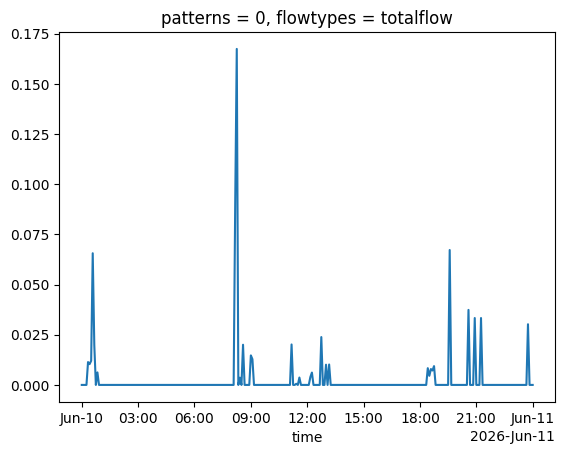

In [14]:
pop.subcatchment_profiles[next(iter(pop.subcatchment_profiles))].plot()

In [15]:
pop.subcatchment_profiles


{'SO40515201': <xarray.DataArray (time: 289, patterns: 1)> Size: 2kB
 array([[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.01139221],
        [0.01036   ],
        [0.01203088],
        [0.06562298],
        [0.01990564],
        [0.        ],
        [0.00622866],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
 ...
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.03024   ],
        [0.        ],
        [0.        ],
        [0.        ]])
 Coordinates:
   * patterns   (patterns) int6

Subcatchment: SO40515201


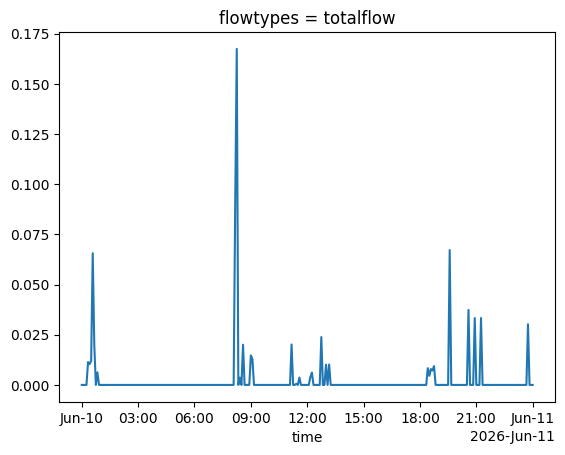

In [16]:
# Plot the aggregated consumption profile for the first subcatchment, averaged over patterns
first_sub = next(iter(pop.subcatchment_profiles))
pop.subcatchment_profiles[first_sub].mean('patterns').plot()
print(f"Subcatchment: {first_sub}")


Subcatchment: SO40515201


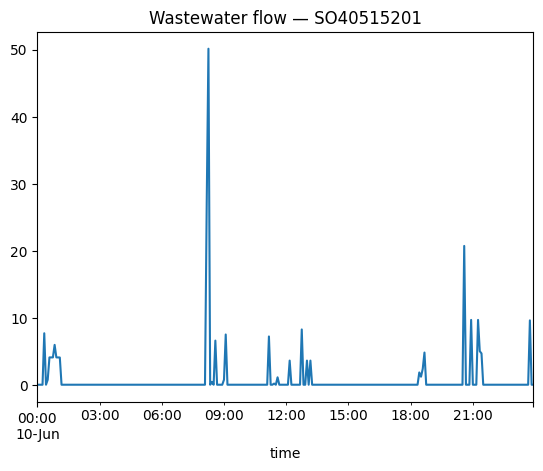

In [17]:
# Plot the aggregated wastewater flow profile for the first subcatchment
first_sub = next(iter(pop.subcatchment_ww_profiles))
ww = pop.subcatchment_ww_profiles[first_sub]['ww_profile']
ww.set_index('time')['flow'].plot(title=f"Wastewater flow — {first_sub}")
print(f"Subcatchment: {first_sub}")


All the objects are still accessible. Here we can view the subcatchments and the houses contained within them, categorised by the occupancy type.

In [18]:
m = pop.subcatchments.explore(name='houses')

pop.houses.explore(m=m, name='houses', column='occupancy_type')

folium.LayerControl().add_to(m)

m

## 4) Exporting consumption profiles for InfoWorks WS

`pop.subcatchment_profiles` holds aggregated water consumption per zone as xarray DataArrays (values in L/s). These can be exported directly to InfoWorks WS demand diagram `.ddg` format using `generate_ws_ddg` from `pysimdeum.tools.infoworks`.

Two files are written per call:
* `SPG_zone_pattern_file.ddg` — the diurnal demand pattern for each zone
* `SPG_zone_base_demand_file.txt` — the mean flow per zone (the base demand node attribute in InfoWorks WS)

The function handles simulation runs of any length: if the run is shorter than 7 days it wraps cyclically to fill; if longer it crops to 7 days (the maximum InfoWorks WS supports).

To export **both** consumption (WS) and wastewater (ICM) at the same time, call `generate_ws_ddg` and `generate_icm_csv` back-to-back — they each write to their own output directory and operate independently.


In [19]:
pop.subcatchment_ww_profiles

{'SO40515201': {'daily_flow': {datetime.date(2026, 6, 10): 228.18828289883882},
  'hourly_average': {datetime.date(2026, 6, 10): 9.507845120784951},
  'ww_profile':                    time      flow         n         p       cod      bod5  \
  0   2026-06-10 00:00:00  0.000000  0.000000  0.000000  0.000000  0.000000   
  1   2026-06-10 00:05:00  0.000000  0.000000  0.000000  0.000000  0.000000   
  2   2026-06-10 00:10:00  0.000000  0.000000  0.000000  0.000000  0.000000   
  3   2026-06-10 00:15:00  0.000000  0.000000  0.000000  0.000000  0.000000   
  4   2026-06-10 00:20:00  7.677662  0.209051  0.086401  3.610567  1.777034   
  ..                  ...       ...       ...       ...       ...       ...   
  283 2026-06-10 23:35:00  0.000000  0.000000  0.000000  0.000000  0.000000   
  284 2026-06-10 23:40:00  0.000000  0.000000  0.000000  0.000000  0.000000   
  285 2026-06-10 23:45:00  9.600000  0.285408  0.029602  0.359496  0.316855   
  286 2026-06-10 23:50:00  0.000000  0.000000  

Each `subcatchment_ww_profiles` dictionary contains a nested dictionary with `daily_flow`, `hourly_average` and the actual wastewater profile `ww_profile`.

In [20]:
pop.subcatchment_ww_profiles[next(iter(pop.subcatchment_ww_profiles))].keys()

dict_keys(['daily_flow', 'hourly_average', 'ww_profile'])

In [21]:
pop.subcatchment_ww_profiles[next(iter(pop.subcatchment_ww_profiles))]['daily_flow']

{datetime.date(2026, 6, 10): 228.18828289883882}

In [22]:
pop.subcatchment_ww_profiles[next(iter(pop.subcatchment_ww_profiles))]['hourly_average']

{datetime.date(2026, 6, 10): 9.507845120784951}

In [23]:
pop.subcatchment_ww_profiles[next(iter(pop.subcatchment_ww_profiles))]['ww_profile']

,time,flow,n,p,cod,bod5,ss,amm
0,2026-06-10 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2026-06-10 00:05:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2026-06-10 00:10:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2026-06-10 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2026-06-10 00:20:00,7.677662,0.209051,0.086401,3.610567,1.777034,0.441766,0.170256
...,...,...,...,...,...,...,...,...
283,2026-06-10 23:35:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
284,2026-06-10 23:40:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
285,2026-06-10 23:45:00,9.600000,0.285408,0.029602,0.359496,0.316855,0.000000,0.070937
286,2026-06-10 23:50:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Wastewater profiles can be exported to InfoWorks ICM calibration CSV format using `generate_icm_csv`. For consumption profiles (InfoWorks WS), use `generate_ws_ddg` — both can be called to the same output directory.


In [24]:
from pysimdeum.tools.infoworks import generate_icm_csv

generate_icm_csv(pop.subcatchment_ww_profiles, './data/infoworks')


## 4) Exporting consumption profiles for InfoWorks

`pop.subcatchment_profiles` holds aggregated water consumption per zone as xarray DataArrays (values in L/s). These can be exported directly to InfoWorks `.ddg` demand diagram format using `generate_zone_ddg` from `pysimdeum.tools.infoworks`.

Two files are written per call:
* `SPG_zone_pattern_file.ddg` — the diurnal demand pattern for each zone
* `SPG_zone_base_demand_file.txt` — the mean flow per zone (the base demand node attribute in InfoWorks WS)

The function handles simulation runs of any length: if the run is shorter than 7 days it wraps cyclically to fill; if longer it crops to 7 days (the maximum InfoWorks WS supports).

In [25]:
from pysimdeum.tools.infoworks import generate_ws_ddg

generate_ws_ddg(
    subcatchment_profiles=pop.subcatchment_profiles,
    output_dir='./data/infoworks_ws',
    Q_option='m3_h',
    patternfile_option=1
)

You can inspect a single zone's aggregated consumption profile before exporting — it is an xarray DataArray with `time` and `patterns` dimensions.

Zone: SO40515201


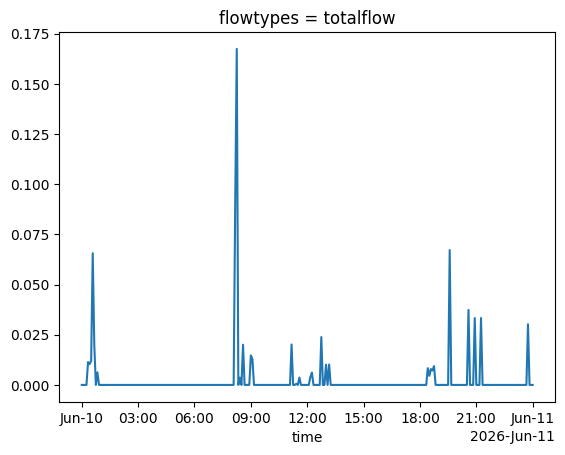

In [26]:
# View the consumption profile for the first zone, averaged over patterns
first_zone = next(iter(pop.subcatchment_profiles))
pop.subcatchment_profiles[first_zone].mean('patterns').plot()
print(f"Zone: {first_zone}")

You can also use `patternfile_option=2` to write one `.ddg` file per day of the week (7 files), which matches the alternative MATLAB `writeNonResPatternsToDdg` behaviour.

In [27]:
generate_ws_ddg(
    subcatchment_profiles=pop.subcatchment_profiles,
    output_dir='./data/infoworks_ws',
    Q_option='m3_h',
    patternfile_option=2
)